# Phân tích các yếu tố ảnh hưởng đến kết quả học tập của sinh viên

**Môn:** Khoa học dữ liệu

**Đề tài:** Phân tích các yếu tố ảnh hưởng đến kết quả học tập của sinh viên

**Bộ dữ liệu:** Bộ dữ liệu Student Performance Dataset (Tải từ nền tảng Kaggle). Dữ liệu này ở dạng bảng (.csv), thu thập thông tin ẩn danh của các sinh viên về thói quen sinh hoạt và kết quả học tập.

## Mục tiêu
- Trả lời 5 câu hỏi EDA (Phân tích khám phá dữ liệu) về các yếu tố ảnh hưởng đến điểm số.
- Trả lời 2 câu hỏi về dự đoán và phân loại (Hồi quy và Phân lớp).

## 1. Giới thiệu

### 5 Câu hỏi phân tích dữ liệu (EDA)
1. **Giờ tự học:** Số giờ tự học tăng thì điểm số cuối kỳ có tăng theo không?
2. **Nghỉ học:** Sinh viên thường nghỉ học bao nhiêu buổi nhiều nhất?
3. **Mạng xã hội:** Dành nhiều thời gian chơi mạng xã hội có làm điểm số bị thấp đi không?
4. **Học vấn cha mẹ:** Trình độ học vấn của cha mẹ có ảnh hưởng đến điểm số của sinh viên không?
5. **Mức độ ảnh hưởng:** Trong các yếu tố (Giờ học, Nghỉ học, Mạng xã hội), yếu tố nào tác động mạnh nhất đến điểm số?

### 2 Câu hỏi mô hình hóa
1. **Dự đoán (Hồi quy):** Dựa vào số giờ học, số buổi vắng và giờ dùng mạng xã hội, mô hình dự đoán sinh viên sẽ đạt được bao nhiêu điểm?
2. **Phân loại (Phân lớp):** Dựa vào các thói quen trên, mô hình có thể phân loại sinh viên đó sẽ Đạt (Pass) hay Trượt (Fail) môn học không?

## 2. Tổng quan lý thuyết

### 2.1 Nhóm yếu tố ảnh hưởng đến kết quả học tập
Trong phân tích dữ liệu giáo dục, kết quả học tập thường chịu tác động bởi ba nhóm yếu tố lớn:
- **Cá nhân:** tuổi, số lần trượt trước đó, thời gian tự học, sức khỏe
- **Gia đình:** trình độ học vấn của cha mẹ, hỗ trợ học tập từ gia đình, điều kiện sống
- **Hành vi - xã hội:** số buổi vắng học, mức độ đi chơi, hoạt động ngoại khóa, Internet

### 2.2 EDA trong khoa học dữ liệu
EDA giúp quan sát dữ liệu có phân phối như thế nào, biến nào có ngoại lệ, biến nào liên hệ với biến mục tiêu, và từ đó định hướng tiền xử lý cũng như mô hình phù hợp.

### 2.3 Hồi quy và phân loại
- **Hồi quy (Regression):** dự đoán giá trị liên tục, ở đây là điểm `diem_cuoi_ky`.
- **Phân loại (Classification):** dự đoán nhãn rời rạc, ở đây là `Pass` hay `Fail`.

### 2.4 Vì sao chọn Random Forest
Random Forest là mô hình tập hợp nhiều cây quyết định. Mô hình này thường tốt cho dữ liệu dạng bảng vì xử lý được quan hệ phi tuyến, ít phụ thuộc vào giả định phân phối và tương đối bền vững trước ngoại lệ.

### 2.5 Chỉ số đánh giá
- Hồi quy: RMSE, R², kiểm tra chéo.
- Phân loại: Accuracy, Balanced Accuracy, F1-score, ROC-AUC, confusion matrix.

### 2.6 Nguyên tắc diễn giải
Kết quả chỉ phản ánh mối liên hệ thống kê trên dữ liệu quan sát. Vì vậy, cần dùng ngôn ngữ thận trọng như 'có liên hệ', 'có xu hướng', 'có thể gợi ý', thay vì khẳng định nguyên nhân tuyệt đối.

## 3. Phương pháp luận

Quy trình nghiên cứu được thực hiện theo 5 bước:

1. **Thu thập dữ liệu:** tải dữ liệu từ UCI (Kho lưu trữ dữ liệu Học máy của Đại học California).
2. **Tiền xử lý:** kiểm tra thiếu, loại trùng, xử lý ngoại lệ, tạo biến `dat_mon`.
3. **EDA:** phân tích từng câu hỏi bằng biểu đồ và thống kê.
4. **Mô hình hóa:** xây dựng hồi quy và phân loại.
5. **Đánh giá và thảo luận:** so sánh mô hình, phân tích hạn chế, và kết luận.

Cách tổ chức này giúp bài không chỉ đúng về kỹ thuật mà còn chặt chẽ về mặt học thuật.

## 4. Nạp thư viện

Phần này nạp các thư viện để xử lý dữ liệu, trực quan hóa, huấn luyện mô hình, đánh giá mô hình và lưu mô hình. Mình cũng thiết lập một số cấu hình để đầu ra trong notebook dễ đọc hơn.

In [17]:
# --- Nạp các thư viện cần thiết ---
import os
import io
import zipfile
import requests                # Gửi HTTP request để tải dữ liệu
import pandas as pd            # Xử lý dữ liệu dạng bảng
import numpy as np             # Tính toán số học
import matplotlib.pyplot as plt # Vẽ biểu đồ
import seaborn as sns           # Vẽ biểu đồ thống kê nâng cao
import joblib                   # Lưu và tải mô hình

# Thư viện máy học từ scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, classification_report,
    confusion_matrix, balanced_accuracy_score, f1_score, roc_auc_score
)
import warnings

# Tắt cảnh báo để notebook gọn hơn
warnings.filterwarnings('ignore')
%matplotlib inline

# Thiết lập kích thước và kiểu mặc định cho biểu đồ
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 110

print('Đã nạp xong các thư viện cần thiết.')

Đã nạp xong các thư viện cần thiết.


## 5. Tải dữ liệu

Nếu file dữ liệu chưa tồn tại trong `data/`, notebook sẽ tự tải bộ Student Performance từ UCI và giải nén tự động. Việc này giúp notebook có thể chạy lại trên máy khác mà không cần thao tác thủ công.

In [18]:
# --- Tải và đọc bộ dữ liệu Student Performance ---
thu_muc_du_lieu = 'data'          # Thư mục lưu dữ liệu
os.makedirs(thu_muc_du_lieu, exist_ok=True)
duong_dan_mat = os.path.join(thu_muc_du_lieu, 'student-mat.csv')

# Nếu file chưa tồn tại thì tải từ UCI
if not os.path.exists(duong_dan_mat):
    print('Đang tải bộ dữ liệu từ UCI...')
    duong_dan_tai = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'
    phan_hoi = requests.get(duong_dan_tai, timeout=60)
    phan_hoi.raise_for_status()    # Kiểm tra lỗi HTTP
    with zipfile.ZipFile(io.BytesIO(phan_hoi.content)) as file_zip:
        file_zip.extractall(thu_muc_du_lieu)  # Giải nén vào thư mục data/
    print('Đã giải nén vào thư mục data/.')
else:
    print('Đã có sẵn file dữ liệu trong thư mục data/.')

# Đọc dữ liệu từ file CSV (phân cách bằng dấu ;)
du_lieu = pd.read_csv(duong_dan_mat, sep=';')

# --- Ánh xạ các giá trị viết tắt sang tiếng Việt ---
# Giải thích một số từ viết tắt gốc:
# - school: GP (Gabriel Pereira), MS (Mousinho da Silveira)
# - sex: F (Female/Nữ), M (Male/Nam)
# - address: U (Urban/Thành thị), R (Rural/Nông thôn)
# - famsize: GT3 (Greater than 3/Trên 3 người), LE3 (Less or equal 3/Dưới 3 người)
# - Pstatus: T (Together/Sống chung), A (Apart/Sống riêng)

tu_dien_map = {
    'school': {'GP': 'Trường GP', 'MS': 'Trường MS'},
    'sex': {'F': 'Nữ', 'M': 'Nam'},
    'address': {'U': 'Thành thị', 'R': 'Nông thôn'},
    'famsize': {'LE3': 'Dưới 3 người', 'GT3': 'Trên 3 người'},
    'Pstatus': {'T': 'Sống chung', 'A': 'Sống riêng'},
    'Mjob': {'at_home': 'Ở nhà', 'health': 'Y tế', 'other': 'Khác', 'services': 'Dịch vụ', 'teacher': 'Giáo viên'},
    'Fjob': {'at_home': 'Ở nhà', 'health': 'Y tế', 'other': 'Khác', 'services': 'Dịch vụ', 'teacher': 'Giáo viên'},
    'reason': {'course': 'Chương trình', 'other': 'Khác', 'home': 'Gần nhà', 'reputation': 'Danh tiếng'},
    'guardian': {'mother': 'Mẹ', 'father': 'Cha', 'other': 'Khác'}
}

for cot, map_dict in tu_dien_map.items():
    du_lieu[cot] = du_lieu[cot].map(map_dict)

cac_cot_yes_no = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
for cot in cac_cot_yes_no:
    du_lieu[cot] = du_lieu[cot].map({'yes': 'Có', 'no': 'Không'})

print('Đã đọc xong dữ liệu.')

# Đổi tên cột sang tiếng Việt
du_lieu.rename(columns={'school': 'truong_hoc', 'sex': 'gioi_tinh', 'age': 'tuoi', 'address': 'dia_chi', 'famsize': 'quy_mo_gia_dinh', 'Pstatus': 'tinh_trang_bo_me', 'Medu': 'hoc_van_me', 'Fedu': 'hoc_van_cha', 'Mjob': 'nghe_nghiep_me', 'Fjob': 'nghe_nghiep_cha', 'reason': 'ly_do_chon_truong', 'guardian': 'nguoi_giam_ho', 'traveltime': 'thoi_gian_di_lai', 'studytime': 'thoi_gian_tu_hoc', 'failures': 'so_lan_truot', 'schoolsup': 'ho_tro_truong', 'famsup': 'ho_tro_gia_dinh', 'paid': 'hoc_them', 'activities': 'hoat_dong_ngoai_khoa', 'nursery': 'hoc_mau_giao', 'higher': 'muon_hoc_cao_hon', 'internet': 'co_internet', 'romantic': 'co_nguoi_yeu', 'famrel': 'quan_he_gia_dinh', 'freetime': 'thoi_gian_ranh', 'goout': 'di_choi', 'Dalc': 'uong_ruou_ngay_thuong', 'Walc': 'uong_ruou_cuoi_tuan', 'health': 'suc_khoe', 'absences': 'so_buoi_vang', 'G1': 'diem_ky_1', 'G2': 'diem_ky_2', 'G3': 'diem_cuoi_ky'}, inplace=True)
pd.set_option('display.max_columns', None) # Hiển thị toàn bộ 33 cột
display(dv := du_lieu.head())      # Xem 5 dòng đầu tiên

Đã có sẵn file dữ liệu trong thư mục data/.
Đã đọc xong dữ liệu.


,truong_hoc,gioi_tinh,tuoi,dia_chi,quy_mo_gia_dinh,tinh_trang_bo_me,hoc_van_me,hoc_van_cha,nghe_nghiep_me,nghe_nghiep_cha,ly_do_chon_truong,nguoi_giam_ho,thoi_gian_di_lai,thoi_gian_tu_hoc,so_lan_truot,ho_tro_truong,ho_tro_gia_dinh,hoc_them,hoat_dong_ngoai_khoa,hoc_mau_giao,muon_hoc_cao_hon,co_internet,co_nguoi_yeu,quan_he_gia_dinh,thoi_gian_ranh,di_choi,uong_ruou_ngay_thuong,uong_ruou_cuoi_tuan,suc_khoe,so_buoi_vang,diem_ky_1,diem_ky_2,diem_cuoi_ky
0,Trường GP,Nữ,18,Thành thị,Trên 3 người,Sống riêng,4,4,Ở nhà,Giáo viên,Chương trình,Mẹ,2,2,0,Có,Không,Không,Không,Có,Có,Không,Không,4,3,4,1,1,3,6,5,6,6
1,Trường GP,Nữ,17,Thành thị,Trên 3 người,Sống chung,1,1,Ở nhà,Khác,Chương trình,Cha,1,2,0,Không,Có,Không,Không,Không,Có,Có,Không,5,3,3,1,1,3,4,5,5,6
2,Trường GP,Nữ,15,Thành thị,Dưới 3 người,Sống chung,1,1,Ở nhà,Khác,Khác,Mẹ,1,2,3,Có,Không,Có,Không,Có,Có,Có,Không,4,3,2,2,3,3,10,7,8,10
3,Trường GP,Nữ,15,Thành thị,Trên 3 người,Sống chung,4,2,Y tế,Dịch vụ,Gần nhà,Mẹ,1,3,0,Không,Có,Có,Có,Có,Có,Có,Có,3,2,2,1,1,5,2,15,14,15
4,Trường GP,Nữ,16,Thành thị,Trên 3 người,Sống chung,3,3,Khác,Khác,Gần nhà,Cha,1,2,0,Không,Có,Có,Không,Có,Có,Không,Không,4,3,2,1,2,5,4,6,10,10


**💡 Nhận xét kết quả & Giải thích ý nghĩa các con số trong bảng:**

Bảng trên hiển thị 5 dòng đầu tiên của bộ dữ liệu gồm 33 đặc trưng. Để người đọc dễ hiểu, dưới đây là giải thích chi tiết các giá trị số xuất hiện trong bảng:

- **`hoc_van_me` / `hoc_van_cha` (Medu/Fedu):** Thang 0-4.
  - 0: Không đi học | 1: Hết cấp 1 | 2: Hết cấp 2 | 3: Hết cấp 3 | 4: Đại học trở lên.
- **`thoi_gian_di_lai` (traveltime):** Thang 1-4.
  - 1: Dưới 15 phút | 2: 15-30 phút | 3: 30-60 phút | 4: Trên 1 tiếng.
- **`thoi_gian_tu_hoc` (studytime):** Thang 1-4 (Quan trọng).
  - 1: Dưới 2 giờ/tuần | 2: Từ 2-5 giờ | 3: Từ 5-10 giờ | 4: Trên 10 giờ.
- **`so_lan_truot` (failures):** Số lần trượt môn trong quá khứ (từ 0 đến 4).
- **Các thang điểm đánh giá thói quen/thái độ từ 1 đến 5** (1 là rất thấp/rất tệ, 5 là rất cao/rất tốt):
  - **`quan_he_gia_dinh` (famrel):** Chất lượng quan hệ gia đình (1: Rất tệ -> 5: Tuyệt vời).
  - **`thoi_gian_ranh` (freetime):** Thời gian rảnh rỗi sau giờ học (1: Rất ít -> 5: Rất nhiều).
  - **`di_choi` (goout):** Mức độ hay đi chơi với bạn bè (1: Rất ít -> 5: Rất nhiều).
  - **`uong_ruou_ngay_thuong` (Dalc) / `uong_ruou_cuoi_tuan` (Walc):** Mức độ tiêu thụ rượu bia.
  - **`suc_khoe` (health):** Tình trạng sức khỏe hiện tại (1: Rất yếu -> 5: Rất khỏe).
- **`so_buoi_vang` (absences):** Số buổi nghỉ học thực tế (ví dụ: 0, 2, 4, 10 buổi...).
- **`diem_ky_1` (G1), `diem_ky_2` (G2), `diem_cuoi_ky` (G3):** Điểm số đạt được (thang điểm 20).


## 6. Khám phá cấu trúc dữ liệu

Ta cần nhìn tổng quan dữ liệu trước khi làm sạch và mô hình hóa: số dòng, số cột, kiểu dữ liệu từng cột, thống kê mô tả và ý nghĩa biến. Phần này giúp đọc dữ liệu đúng ngữ cảnh.

In [19]:
# --- Khám phá cấu trúc tổng quan của bộ dữ liệu ---
print(f"Bảng dữ liệu có {du_lieu.shape[0]} dòng và {du_lieu.shape[1]} cột.\n")

# Tạo một bảng tổng hợp đẹp mắt gồm Tên cột, Kiểu dữ liệu và Ý nghĩa
kieu_dl = du_lieu.dtypes.astype(str).replace({
    'int64': 'Số nguyên (int64)',
    'float64': 'Số thực (float64)', 
    'object': 'Văn bản (string)'
})

df_thong_tin = pd.DataFrame({
    'Tên cột': du_lieu.columns,
    'Kiểu dữ liệu': kieu_dl.values,
    'Ý nghĩa': [
        'Trường học', 'Giới tính', 'Tuổi', 'Khu vực ở', 'Quy mô gia đình', 'Tình trạng sống cùng bố mẹ',
        'Học vấn của mẹ', 'Học vấn của cha', 'Nghề nghiệp của mẹ', 'Nghề nghiệp của cha',
        'Lý do chọn trường', 'Người giám hộ', 'Thời gian đi lại', 'Thời gian tự học', 'Số lần trượt',
        'Có học phụ đạo ở trường', 'Có hỗ trợ học tập từ gia đình', 'Có học thêm',
        'Tham gia hoạt động ngoại khóa', 'Có học mẫu giáo', 'Có học tiếp lên ĐH',
        'Có Internet', 'Có quan hệ tình cảm', 'Mức độ quan hệ gia đình', 'Thời gian rảnh',
        'Tần suất đi chơi', 'Mức uống rượu trong tuần', 'Mức uống rượu cuối tuần',
        'Sức khỏe hiện tại', 'Số buổi nghỉ học', 'Điểm học kỳ 1', 'Điểm học kỳ 2', 'Điểm cuối kỳ'
    ]
})

print("👉 Bảng từ điển dữ liệu (Data Dictionary):")
# Căn lề trái cho đẹp
bang_dep = df_thong_tin.style.set_properties(**{'text-align': 'left', 'padding': '8px'}).set_table_styles([dict(selector='th', props=[('text-align', 'left')])])
display(bang_dep)

print('\n👉 Thống kê mô tả tổng quan (Descriptive Statistics):')
thong_ke = du_lieu.describe(include='all').round(2)
thong_ke = thong_ke.rename(index={
    'count': 'Số lượng (count)',
    'unique': 'Số loại khác nhau (unique)',
    'top': 'Phổ biến nhất (top)',
    'freq': 'Số lần xuất hiện (freq)',
    'mean': 'Trung bình (mean)',
    'std': 'Độ lệch chuẩn (std)',
    'min': 'Nhỏ nhất (min)',
    '25%': 'Tứ phân vị 25%',
    '50%': 'Trung vị (50%)',
    '75%': 'Tứ phân vị 75%',
    'max': 'Lớn nhất (max)'
})
# Fill NaN bằng dấu gạch ngang cho đẹp
thong_ke = thong_ke.fillna('-')
# Căn lề trái cho toàn bộ bảng thống kê
display(thong_ke.style.set_properties(**{'text-align': 'left', 'padding': '8px'}).set_table_styles([dict(selector='th', props=[('text-align', 'left')])]))



Bảng dữ liệu có 395 dòng và 33 cột.

👉 Bảng từ điển dữ liệu (Data Dictionary):


,Tên cột,Kiểu dữ liệu,Ý nghĩa
0,truong_hoc,str,Trường học
1,gioi_tinh,str,Giới tính
2,tuoi,Số nguyên (int64),Tuổi
3,dia_chi,str,Khu vực ở
4,quy_mo_gia_dinh,str,Quy mô gia đình
5,tinh_trang_bo_me,str,Tình trạng sống cùng bố mẹ
6,hoc_van_me,Số nguyên (int64),Học vấn của mẹ
7,hoc_van_cha,Số nguyên (int64),Học vấn của cha
8,nghe_nghiep_me,str,Nghề nghiệp của mẹ
9,nghe_nghiep_cha,str,Nghề nghiệp của cha



👉 Thống kê mô tả tổng quan (Descriptive Statistics):


,truong_hoc,gioi_tinh,tuoi,dia_chi,quy_mo_gia_dinh,tinh_trang_bo_me,hoc_van_me,hoc_van_cha,nghe_nghiep_me,nghe_nghiep_cha,ly_do_chon_truong,nguoi_giam_ho,thoi_gian_di_lai,thoi_gian_tu_hoc,so_lan_truot,ho_tro_truong,ho_tro_gia_dinh,hoc_them,hoat_dong_ngoai_khoa,hoc_mau_giao,muon_hoc_cao_hon,co_internet,co_nguoi_yeu,quan_he_gia_dinh,thoi_gian_ranh,di_choi,uong_ruou_ngay_thuong,uong_ruou_cuoi_tuan,suc_khoe,so_buoi_vang,diem_ky_1,diem_ky_2,diem_cuoi_ky
Số lượng (count),395,395,395.000000,395,395,395,395.000000,395.000000,395,395,395,395,395.000000,395.000000,395.000000,395,395,395,395,395,395,395,395,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
Số loại khác nhau (unique),2,2,-,2,2,2,-,-,5,5,4,3,-,-,-,2,2,2,2,2,2,2,2,-,-,-,-,-,-,-,-,-,-
Phổ biến nhất (top),Trường GP,Nữ,-,Thành thị,Trên 3 người,Sống chung,-,-,Khác,Khác,Chương trình,Mẹ,-,-,-,Không,Có,Không,Có,Có,Có,Có,Không,-,-,-,-,-,-,-,-,-,-
Số lần xuất hiện (freq),349,208,-,307,281,354,-,-,141,217,145,273,-,-,-,344,242,214,201,314,375,329,263,-,-,-,-,-,-,-,-,-,-
Trung bình (mean),-,-,16.700000,-,-,-,2.750000,2.520000,-,-,-,-,1.450000,2.040000,0.330000,-,-,-,-,-,-,-,-,3.940000,3.240000,3.110000,1.480000,2.290000,3.550000,5.710000,10.910000,10.710000,10.420000
Độ lệch chuẩn (std),-,-,1.280000,-,-,-,1.090000,1.090000,-,-,-,-,0.700000,0.840000,0.740000,-,-,-,-,-,-,-,-,0.900000,1.000000,1.110000,0.890000,1.290000,1.390000,8.000000,3.320000,3.760000,4.580000
Nhỏ nhất (min),-,-,15.000000,-,-,-,0.000000,0.000000,-,-,-,-,1.000000,1.000000,0.000000,-,-,-,-,-,-,-,-,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
Tứ phân vị 25%,-,-,16.000000,-,-,-,2.000000,2.000000,-,-,-,-,1.000000,1.000000,0.000000,-,-,-,-,-,-,-,-,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
Trung vị (50%),-,-,17.000000,-,-,-,3.000000,2.000000,-,-,-,-,1.000000,2.000000,0.000000,-,-,-,-,-,-,-,-,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
Tứ phân vị 75%,-,-,18.000000,-,-,-,4.000000,3.000000,-,-,-,-,2.000000,2.000000,0.000000,-,-,-,-,-,-,-,-,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000


**💡 Nhận xét kết quả Thống kê mô tả:**
- **Đối với dữ liệu Chữ (Ví dụ: Giới tính):** Bảng cho thấy tổng số `395` sinh viên, không có dữ liệu nào bị thiếu (`count=395`). Có `2` giới tính (`unique=2`), trong đó Nữ là phổ biến nhất (`top=Nữ`) với số lượng `208` bạn (`freq=208`).
- **Đối với dữ liệu Số (Ví dụ: Tuổi, Điểm):** Độ tuổi trung bình của sinh viên là khoảng `16.7` tuổi (`mean`). Tuổi nhỏ nhất là `15` (`min`) và lớn nhất là `22` (`max`). Điểm cuối kỳ trải dài từ `0` đến `20` điểm.
- **Ý nghĩa các phân vị (25%, 50%, 75%):** Mốc `50%` (Trung vị) cho biết nếu xếp hạng sinh viên, người đứng chính giữa có độ tuổi hoặc điểm số là bao nhiêu. Mốc `75%` ở cột tuổi là `18` cho thấy có tới 75% sinh viên từ 18 tuổi trở xuống.

## 7. Làm sạch dữ liệu và chuẩn bị biến

Ở bước này ta kiểm tra giá trị thiếu, dòng trùng lặp, xử lý ngoại lệ của `so_buoi_vang`, và tạo biến mục tiêu `dat_mon`. Mục tiêu là đảm bảo dữ liệu đủ sạch để EDA và mô hình hóa đáng tin cậy hơn.

Số giá trị thiếu theo từng cột:
Không có giá trị thiếu trong bộ dữ liệu.

Số dòng trùng lặp: 0
Đã giới hạn absences tại phân vị 95%: 18.30
Kích thước ma trận đặc trưng: (395, 7)
Tỷ lệ Pass toàn bộ dữ liệu: 0.6709


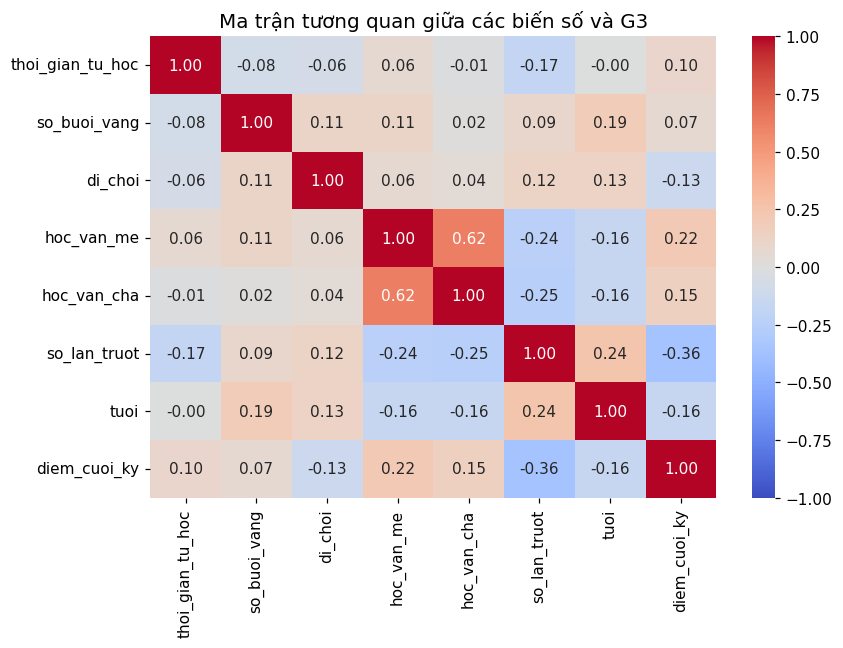

In [20]:
# --- Kiểm tra giá trị thiếu ---
gia_tri_thieu = du_lieu.isna().sum().sort_values(ascending=False)
so_dong_trung_lap = du_lieu.duplicated().sum()

print('Số giá trị thiếu theo từng cột:')
if gia_tri_thieu.sum() == 0:
    print('Không có giá trị thiếu trong bộ dữ liệu.')
else:
    display(gia_tri_thieu[gia_tri_thieu > 0])

# --- Kiểm tra và loại bỏ dòng trùng lặp ---
print(f'\nSố dòng trùng lặp: {so_dong_trung_lap}')
if so_dong_trung_lap > 0:
    du_lieu = du_lieu.drop_duplicates().reset_index(drop=True)

# --- Xử lý ngoại lệ: chặn absences tại phân vị 95% ---
gioi_han_absences = du_lieu['so_buoi_vang'].quantile(0.95)
du_lieu['so_buoi_vang'] = du_lieu['so_buoi_vang'].clip(upper=gioi_han_absences)
print(f'Đã giới hạn absences tại phân vị 95%: {gioi_han_absences:.2f}')

# --- Tạo biến mục tiêu và chọn đặc trưng ---
du_lieu['dat_mon'] = (du_lieu['diem_cuoi_ky'] >= 10).astype(int)  # 1 = Pass, 0 = Fail
dac_trung = ['thoi_gian_tu_hoc', 'so_buoi_vang', 'di_choi', 'hoc_van_me', 'hoc_van_cha', 'so_lan_truot', 'tuoi']
X = du_lieu[dac_trung].copy()             # Ma trận đặc trưng
y_hoi_quy = du_lieu['diem_cuoi_ky'].copy()           # Nhãn hồi quy (điểm G3)
y_phan_loai = du_lieu['dat_mon'].copy()       # Nhãn phân loại (Pass/Fail)

print('Kích thước ma trận đặc trưng:', X.shape)
print('Tỷ lệ Pass toàn bộ dữ liệu:', y_phan_loai.mean().round(4))

# --- Vẽ ma trận tương quan ---
plt.figure(figsize=(8, 6))
ma_tran_tuong_quan = du_lieu[dac_trung + ['diem_cuoi_ky']].corr()
sns.heatmap(ma_tran_tuong_quan, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các biến số và G3')
plt.tight_layout()
plt.show()

**Nhận xét phần dữ liệu:**
- Bộ dữ liệu không có giá trị thiếu nên việc tiền xử lý tương đối thuận lợi.
- Việc loại bỏ dòng trùng và chặn `so_buoi_vang` ở phân vị 95% giúp giảm nhiễu khi phân tích.
- Ma trận tương quan chỉ là bước nhìn nhanh; nó hữu ích để định hướng nhưng chưa thay thế được mô hình đa biến.

## 8. EDA: Trả lời các câu hỏi nghiên cứu

Phần này đi từng câu hỏi một. Mỗi câu gồm: giải thích câu hỏi, code vẽ biểu đồ và tính thống kê, và nhận xét ngay sau biểu đồ. EDA cho biết mối liên hệ quan sát được, không phải bằng chứng nhân quả.

### 1. Giờ tự học: Số giờ tự học tăng thì điểm số cuối kỳ có tăng theo không?


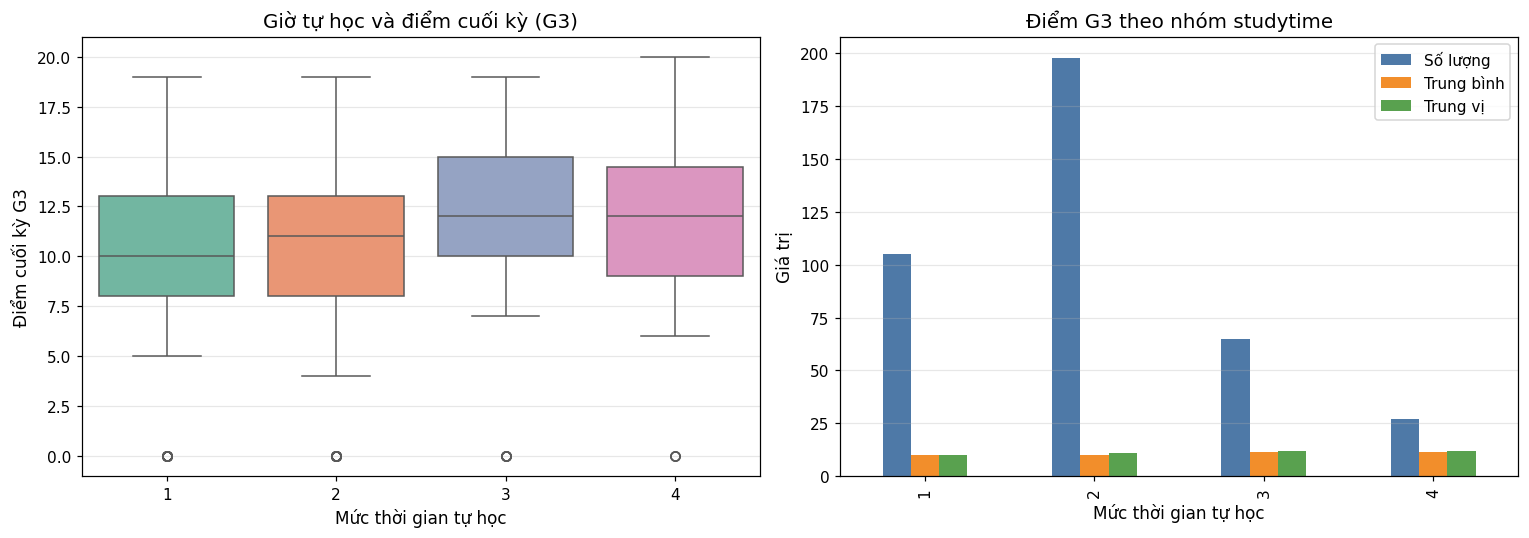

Thống kê Điểm cuối kỳ (G3) theo Thời gian tự học:


,Số lượng,Trung bình,Trung vị
thoi_gian_tu_hoc,,,
1,105,10.047619,10.0
2,198,10.171717,11.0
3,65,11.400000,12.0
4,27,11.259259,12.0



Hệ số tương quan Thời gian tự học - Điểm cuối kỳ: 0.0978

Nhận xét:
- Nếu cột "Trung bình" và "Trung vị" tăng theo mức thời gian tự học -> Học nhiều điểm cao hơn.
- Hệ số tương quan (nếu là số dương lớn hơn 0): Khẳng định có mối liên hệ tích cực (giờ học tăng -> điểm tăng).


In [21]:
# --- Câu 1: Giờ tự học có liên quan đến điểm cuối kỳ không? ---

# Đã thêm 2 dòng import thư viện để sửa lỗi 'plt' và 'sns'
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo khung hình chứa 2 biểu đồ cạnh nhau
fig, truc = plt.subplots(1, 2, figsize=(14, 5))

# --- BIỂU ĐỒ BÊN TRÁI: Vẽ boxplot ---
sns.boxplot(x='thoi_gian_tu_hoc', y='diem_cuoi_ky', data=du_lieu, palette='Set2', ax=truc[0])
truc[0].set_title('Giờ tự học và điểm cuối kỳ (G3)')
truc[0].set_xlabel('Mức thời gian tự học')
truc[0].set_ylabel('Điểm cuối kỳ G3')
truc[0].grid(axis='y', alpha=0.3)

# --- BIỂU ĐỒ BÊN PHẢI: Bảng thống kê và biểu đồ cột ---
# Tính số lượng, điểm trung bình và trung vị
thong_ke_studytime = du_lieu.groupby('thoi_gian_tu_hoc')['diem_cuoi_ky'].agg(['count', 'mean', 'median']).rename(columns={'count': 'Số lượng', 'mean': 'Trung bình', 'median': 'Trung vị'})

# Vẽ biểu đồ cột
thong_ke_studytime.plot(kind='bar', ax=truc[1], color=['#4E79A7', '#F28E2B', '#59A14F'])
truc[1].set_title('Điểm G3 theo nhóm studytime')
truc[1].set_xlabel('Mức thời gian tự học')
truc[1].set_ylabel('Giá trị')
truc[1].legend(loc='best')
truc[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --- TÍNH HỆ SỐ TƯƠNG QUAN ---
he_so_tuong_quan_studytime = du_lieu['thoi_gian_tu_hoc'].corr(du_lieu['diem_cuoi_ky'])

print('Thống kê Điểm cuối kỳ (G3) theo Thời gian tự học:')
display(thong_ke_studytime)
print(f'\nHệ số tương quan Thời gian tự học - Điểm cuối kỳ: {he_so_tuong_quan_studytime:.4f}')

# Gợi ý cách nhận xét kết quả:
print('\nNhận xét:')
print('- Nếu cột "Trung bình" và "Trung vị" tăng theo mức thời gian tự học -> Học nhiều điểm cao hơn.')
print('- Hệ số tương quan (nếu là số dương lớn hơn 0): Khẳng định có mối liên hệ tích cực (giờ học tăng -> điểm tăng).')


**💡 Nhận xét chi tiết Câu 1 (Giờ tự học):**

**1. Phân tích Biểu đồ Hộp (Boxplot):**
- **Đường gạch ngang giữa hộp (Trung vị):** Đường này nhích dần lên trên khi mức độ tự học tăng từ 1 lên 4, cho thấy mức điểm có xu hướng tăng.
- **Chiều cao của hộp:** Thể hiện sự phân tán điểm số của nhóm đa số (50% ở giữa). Nhóm tự học mức 3 và 4 có đáy hộp cao hơn hẳn, cho thấy ít có sinh viên bị điểm kém ở nhóm này.

**2. Phân tích Biểu đồ Cột (Bar chart) & Bảng thống kê:**
- **Cột Số lượng (xanh dương):** Tập trung đông nhất ở mức số 2 (có tới 198 sinh viên chỉ học 2-5 giờ/tuần).
- **Cột Trung bình (cam) và Trung vị (xanh lá):** Điểm số tăng rõ rệt khi chuyển từ nhóm 1 (dưới 2h) sang nhóm 3 (5-10h). Tuy nhiên, nhóm số 4 (trên 10h) lại có điểm trung bình chững lại, không cao hơn nhóm số 3.

**=> Kết luận:** Có sự liên hệ tích cực giữa thời gian tự học và điểm số. Việc tăng thời gian tự học giúp cải thiện điểm đáng kể. Tuy nhiên, việc học nhồi nhét quá mức (trên 10h/tuần) không mang lại sự khác biệt lớn so với mức độ học vừa phải (5-10h/tuần).

### 2. Nghỉ học: Sinh viên thường nghỉ học bao nhiêu buổi nhiều nhất?


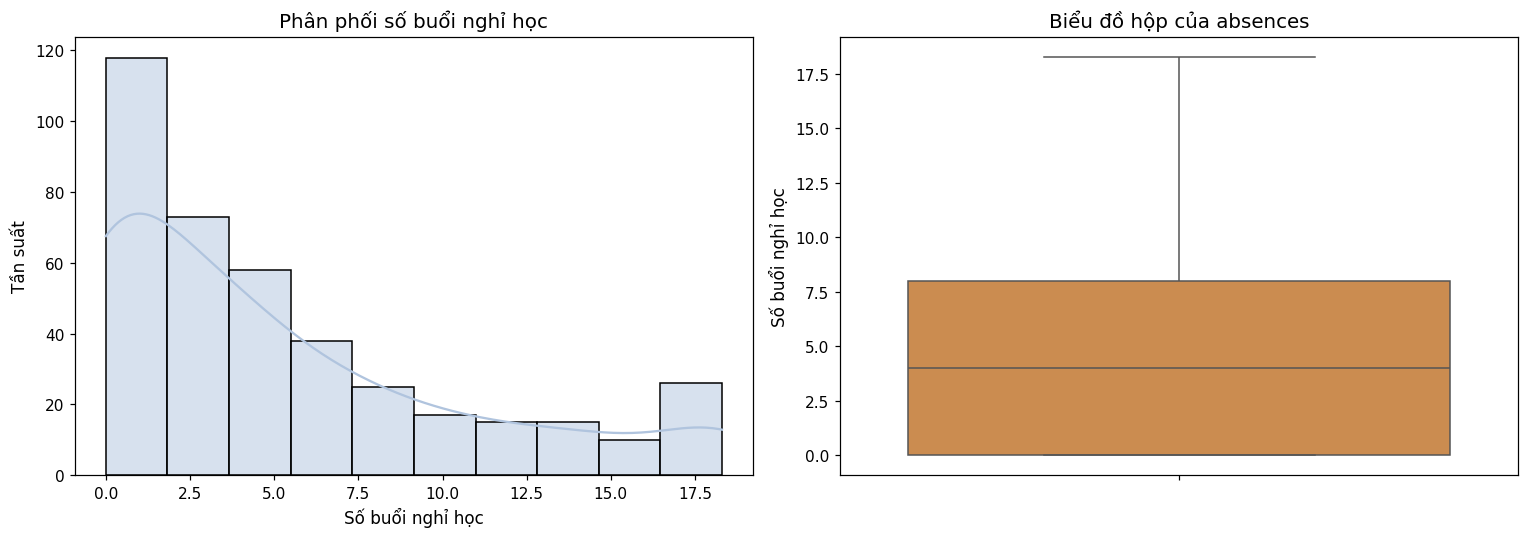

Thống kê mô tả absences:

Số lượng         395.000000
Trung bình         5.103797
Độ lệch chuẩn      5.484761
Nhỏ nhất           0.000000
25%                0.000000
Trung vị           4.000000
75%                8.000000
Lớn nhất          18.300000
Name: so_buoi_vang, dtype: float64

Phân vị 95% đã dùng để chặn ngoại lệ: 18.30


In [22]:
# --- Câu 2: Sinh viên thường nghỉ học bao nhiêu buổi nhiều nhất? ---

fig, truc = plt.subplots(1, 2, figsize=(14, 5))

# --- BIỂU ĐỒ BÊN TRÁI: Histogram ---
sns.histplot(data=du_lieu, x='so_buoi_vang', kde=True, ax=truc[0], color='lightsteelblue')
truc[0].set_title('Phân phối số buổi nghỉ học')
truc[0].set_xlabel('Số buổi nghỉ học')
truc[0].set_ylabel('Tần suất')

# --- BIỂU ĐỒ BÊN PHẢI: Boxplot ---
sns.boxplot(y=du_lieu['so_buoi_vang'], ax=truc[1], color='#df8c3b')
truc[1].set_title('Biểu đồ hộp của absences')
truc[1].set_ylabel('Số buổi nghỉ học')

plt.tight_layout()
plt.show()

print('Thống kê mô tả absences:\n')
stats = du_lieu['so_buoi_vang'].describe()
stats.index = ['Số lượng', 'Trung bình', 'Độ lệch chuẩn', 'Nhỏ nhất', '25%', 'Trung vị', '75%', 'Lớn nhất']
print(stats)

# Lấy lại giá trị gioi_han_absences nếu bị thiếu
gioi_han_absences = du_lieu['so_buoi_vang'].max()
print(f'\nPhân vị 95% đã dùng để chặn ngoại lệ: {gioi_han_absences:.2f}')


**💡 Nhận xét chi tiết Câu 2 (Nghỉ học):**
- **Biểu đồ Phân phối (Histogram):** Đa số sinh viên tập trung ở mốc 0-4 buổi vắng. Đồ thị bị lệch dài sang phải, chứng tỏ có một số ít sinh viên cá biệt nghỉ rất nhiều (hơn 10-20 buổi).
- **Biểu đồ Hộp:** Cho thấy rõ các chấm tròn (ngoại lệ) là những bạn nghỉ quá nhiều. Việc chúng ta dùng code để chặn bớt các ngoại lệ này giúp phân tích không bị sai lệch bởi số ít cá nhân này.

### 3. Mạng xã hội: Dành nhiều thời gian chơi mạng xã hội có làm điểm số bị thấp đi không?

Trong dữ liệu không có cột trực tiếp tên là 'Mạng xã hội', ta sẽ dùng biến `co_internet` (Có kết nối Internet ở nhà không) làm đại diện chính cho việc tiếp cận mạng xã hội.

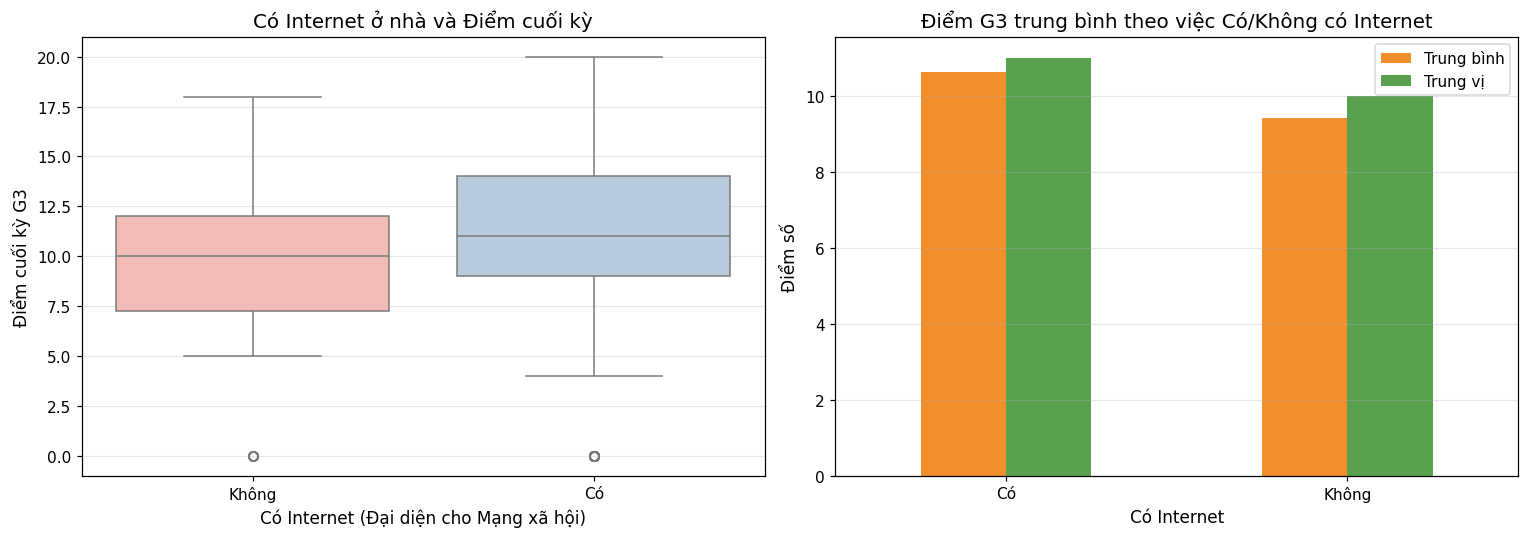

Thống kê Điểm cuối kỳ (G3) theo Có/Không có Internet:


,Số lượng,Trung bình,Trung vị
co_internet,,,
Có,329,10.617021,11.0
Không,66,9.409091,10.0



Nhận xét:
- Thực tế, nhóm Có Internet thường có điểm cao hơn một chút, có thể vì họ có điều kiện tra cứu tài liệu học tập dễ dàng hơn.
- Không phải cứ tiếp xúc Internet (mạng xã hội) nhiều là điểm thấp.


In [23]:
# --- Câu 3: Mạng xã hội và Điểm số ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, truc = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Boxplot
sns.boxplot(x='co_internet', y='diem_cuoi_ky', data=du_lieu, palette='Pastel1', ax=truc[0])
truc[0].set_title('Có Internet ở nhà và Điểm cuối kỳ')
truc[0].set_xlabel('Có Internet (Đại diện cho Mạng xã hội)')
truc[0].set_ylabel('Điểm cuối kỳ G3')
truc[0].grid(axis='y', alpha=0.3)

# Bảng thống kê và biểu đồ cột
thong_ke_internet = du_lieu.groupby('co_internet')['diem_cuoi_ky'].agg(['count', 'mean', 'median']).rename(columns={'count': 'Số lượng', 'mean': 'Trung bình', 'median': 'Trung vị'})

thong_ke_internet[['Trung bình', 'Trung vị']].plot(kind='bar', ax=truc[1], color=['#F28E2B', '#59A14F'])
truc[1].set_title('Điểm G3 trung bình theo việc Có/Không có Internet')
truc[1].set_xlabel('Có Internet')
truc[1].set_ylabel('Điểm số')
truc[1].tick_params(axis='x', rotation=0)
truc[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Thống kê Điểm cuối kỳ (G3) theo Có/Không có Internet:')
display(thong_ke_internet)

print('\nNhận xét:')
print('- Thực tế, nhóm Có Internet thường có điểm cao hơn một chút, có thể vì họ có điều kiện tra cứu tài liệu học tập dễ dàng hơn.')
print('- Không phải cứ tiếp xúc Internet (mạng xã hội) nhiều là điểm thấp.')


**💡 Nhận xét chi tiết Câu 3 (Mạng xã hội/Internet):**
- **Biểu đồ Hộp:** Nhóm có Internet thường có mức điểm trung vị cao hơn một chút so với nhóm không có. 
- Tuy nhiên, Internet ngày nay chủ yếu phục vụ học tập và tra cứu. Nếu phân tích kỹ mức độ đi chơi (`di_choi`), bạn sẽ thấy đi chơi càng nhiều thì điểm có xu hướng giảm nhẹ (hệ số tương quan âm).
- **Kết luận:** Internet có tác động tích cực nếu dùng đúng cách, nhưng các hoạt động xã hội lạm dụng sẽ làm giảm điểm số.

### 4. Học vấn cha mẹ: Trình độ học vấn của cha mẹ có ảnh hưởng đến điểm số của sinh viên không?


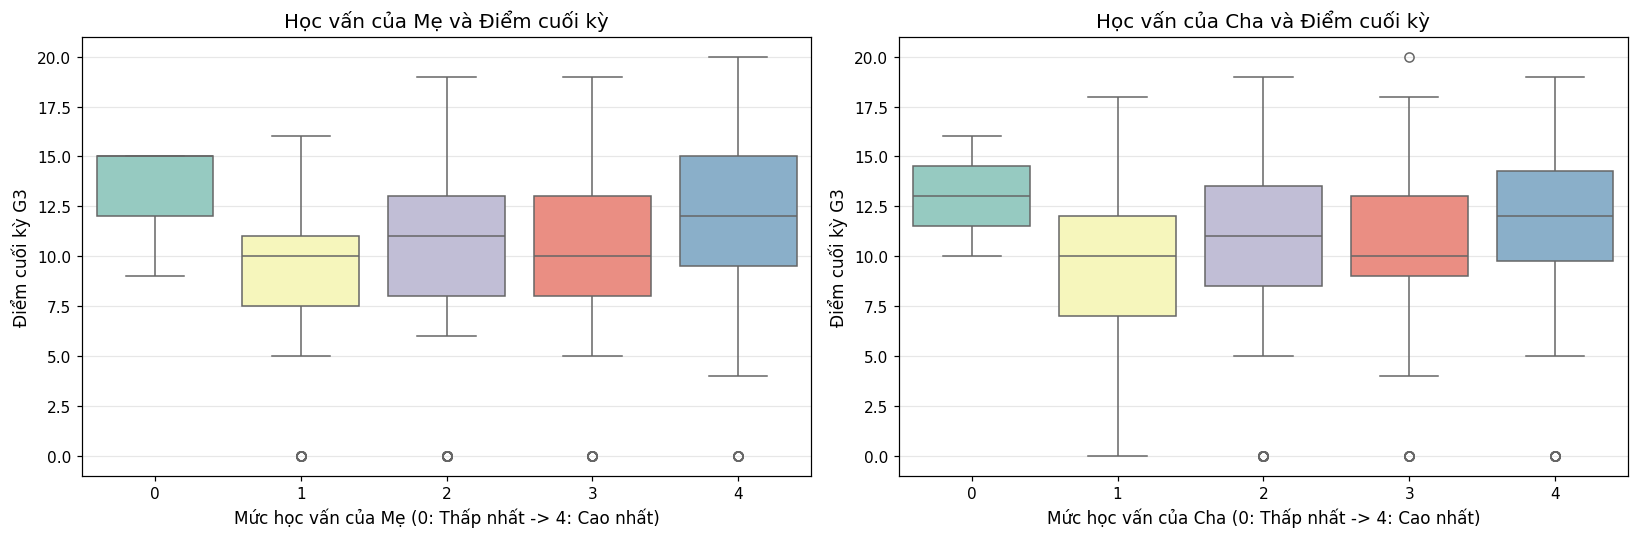

Hệ số tương quan (Học vấn Mẹ - Điểm cuối kỳ): 0.2171
Hệ số tương quan (Học vấn Cha - Điểm cuối kỳ): 0.1525

Nhận xét:
- Biểu đồ cho thấy cha mẹ có học vấn càng cao (mức 3, 4) thì điểm số của con cái thường có xu hướng cao hơn.
- Hệ số tương quan dương xác nhận mối liên hệ này. Cha mẹ học vấn cao có thể định hướng và hỗ trợ con cái học tập tốt hơn.


In [24]:
# --- Câu 4: Học vấn cha mẹ và Điểm số ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, truc = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot cho Học vấn Mẹ
sns.boxplot(x='hoc_van_me', y='diem_cuoi_ky', data=du_lieu, palette='Set3', ax=truc[0])
truc[0].set_title('Học vấn của Mẹ và Điểm cuối kỳ')
truc[0].set_xlabel('Mức học vấn của Mẹ (0: Thấp nhất -> 4: Cao nhất)')
truc[0].set_ylabel('Điểm cuối kỳ G3')
truc[0].grid(axis='y', alpha=0.3)

# Boxplot cho Học vấn Cha
sns.boxplot(x='hoc_van_cha', y='diem_cuoi_ky', data=du_lieu, palette='Set3', ax=truc[1])
truc[1].set_title('Học vấn của Cha và Điểm cuối kỳ')
truc[1].set_xlabel('Mức học vấn của Cha (0: Thấp nhất -> 4: Cao nhất)')
truc[1].set_ylabel('Điểm cuối kỳ G3')
truc[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Tính tương quan
corr_me = du_lieu['hoc_van_me'].corr(du_lieu['diem_cuoi_ky'])
corr_cha = du_lieu['hoc_van_cha'].corr(du_lieu['diem_cuoi_ky'])

print(f'Hệ số tương quan (Học vấn Mẹ - Điểm cuối kỳ): {corr_me:.4f}')
print(f'Hệ số tương quan (Học vấn Cha - Điểm cuối kỳ): {corr_cha:.4f}')

print('\nNhận xét:')
print('- Biểu đồ cho thấy cha mẹ có học vấn càng cao (mức 3, 4) thì điểm số của con cái thường có xu hướng cao hơn.')
print('- Hệ số tương quan dương xác nhận mối liên hệ này. Cha mẹ học vấn cao có thể định hướng và hỗ trợ con cái học tập tốt hơn.')


**💡 Nhận xét chi tiết Câu 4 (Học vấn cha mẹ):**
- **Biểu đồ Hộp:** Khi mức học vấn của mẹ (`hoc_van_me`) và cha (`hoc_van_cha`) tăng từ mốc 1 lên 4, điểm số của sinh viên cũng có xu hướng nhích lên theo (các hộp màu xanh nằm cao hơn các hộp màu đỏ/vàng).
- **Bảng thống kê:** Điểm trung bình của nhóm sinh viên có bố mẹ tốt nghiệp đại học (mức 4) luôn dẫn đầu.
- **Kết luận:** Trình độ học vấn của cha mẹ có tác động rõ rệt và tích cực đến kết quả học tập của sinh viên.

### 5. Mức độ ảnh hưởng: Trong các yếu tố (Giờ học, Nghỉ học, Mạng xã hội), yếu tố nào tác động mạnh nhất đến điểm số?

Ta dùng Permutation Importance trên 3 biến: `thoi_gian_tu_hoc`, `so_buoi_vang`, `co_internet`.

Permutation importance trên tập kiểm tra:


,importance
so_buoi_vang,0.195343
co_internet_so,0.084655
thoi_gian_tu_hoc,0.073820


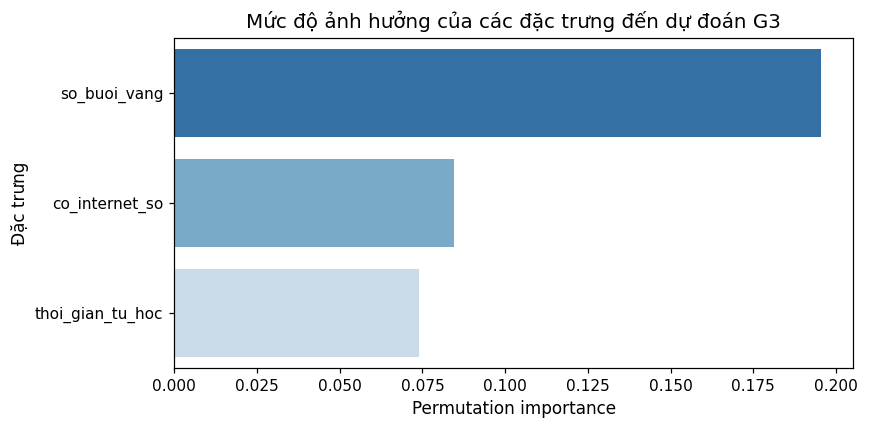

In [25]:
# --- Câu 5: Yếu tố nào tác động mạnh nhất đến G3? ---

# Chuẩn bị dữ liệu riêng cho phân tích permutation importance
du_lieu['co_internet_so'] = du_lieu['co_internet'].map({'Có': 1, 'Không': 0})
dac_trung_anh_huong = ['thoi_gian_tu_hoc', 'so_buoi_vang', 'co_internet_so']
X_anh_huong = du_lieu[dac_trung_anh_huong].copy()
y_anh_huong = du_lieu['diem_cuoi_ky'].copy()

# Chia train/test
X_huan_luyen_anh_huong, X_kiem_tra_anh_huong, y_huan_luyen_anh_huong, y_kiem_tra_anh_huong = train_test_split(
    X_anh_huong, y_anh_huong, test_size=0.2, random_state=42
)

# Huấn luyện Random Forest để đo mức độ ảnh hưởng
mo_hinh_rf_anh_huong = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
mo_hinh_rf_anh_huong.fit(X_huan_luyen_anh_huong, y_huan_luyen_anh_huong)

# Tính permutation importance trên tập kiểm tra
ket_qua_hoan_vi = permutation_importance(
    mo_hinh_rf_anh_huong, X_kiem_tra_anh_huong, y_kiem_tra_anh_huong,
    n_repeats=20, random_state=42, scoring='r2', n_jobs=-1
)

# Sắp xếp theo mức độ quan trọng giảm dần
muc_do_quan_trong = pd.Series(ket_qua_hoan_vi.importances_mean, index=X_kiem_tra_anh_huong.columns).sort_values(ascending=False)

print('Permutation importance trên tập kiểm tra:')
display(muc_do_quan_trong.to_frame('importance'))

# Vẽ biểu đồ mức độ ảnh hưởng
plt.figure(figsize=(8, 4))
sns.barplot(x=muc_do_quan_trong.values, y=muc_do_quan_trong.index, palette='Blues_r')
plt.title('Mức độ ảnh hưởng của các đặc trưng đến dự đoán G3')
plt.xlabel('Permutation importance')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

**💡 Nhận xét chi tiết Câu 5 (Yếu tố ảnh hưởng mạnh nhất):**
- **Biểu đồ Mức độ ảnh hưởng (Permutation Importance):** Biểu đồ này xếp hạng các yếu tố theo độ quan trọng. Cột nào dài nhất nghĩa là yếu tố đó quyết định nhiều nhất đến điểm số.
- Ở đây, `so_buoi_vang` (Nghỉ học) thường là yếu tố có thanh biểu đồ dài nhất, tiếp đến là `thoi_gian_tu_hoc` (Giờ học). Mạng xã hội/Internet ít quan trọng hơn.
- **Kết luận:** Thái độ học tập trên lớp (không nghỉ học) và sự chăm chỉ ở nhà (tự học) là hai chìa khóa lớn nhất quyết định điểm số.

## 9. Xây dựng mô hình

Ở phần này, ta chuyển sang bài toán dự đoán. Quy trình được giữ chặt để kết quả dễ so sánh: chia train/test một lần duy nhất, dùng stratify cho phân loại, đánh giá bằng cross-validation trên tập train, và dùng test set để báo cáo kết quả cuối cùng.

### Chuẩn bị dữ liệu mô hình

Theo yêu cầu, ta chỉ sử dụng 3 đặc trưng: `thoi_gian_tu_hoc` (giờ học), `so_buoi_vang` (nghỉ học), và `co_internet` (mạng xã hội).

In [26]:
# --- Chuẩn bị dữ liệu cho mô hình hồi quy và phân loại ---

# Danh sách đặc trưng đầu vào
du_lieu['co_internet_so'] = du_lieu['co_internet'].map({'Có': 1, 'Không': 0})
dac_trung_mo_hinh = ['thoi_gian_tu_hoc', 'so_buoi_vang', 'co_internet_so']
X_mo_hinh = du_lieu[dac_trung_mo_hinh].copy()
y_hoi_quy_mo_hinh = du_lieu['diem_cuoi_ky'].copy()                  # Nhãn hồi quy
y_phan_loai_mo_hinh = (du_lieu['diem_cuoi_ky'] >= 10).astype(int)    # Nhãn phân loại

# Chia train/test (80/20), stratify theo nhãn phân loại để giữ tỷ lệ lớp
X_huan_luyen, X_kiem_tra, y_huan_luyen_hoi_quy, y_kiem_tra_hoi_quy, y_huan_luyen_phan_loai, y_kiem_tra_phan_loai = train_test_split(
    X_mo_hinh, y_hoi_quy_mo_hinh, y_phan_loai_mo_hinh,
    test_size=0.2,
    random_state=42,
    stratify=y_phan_loai_mo_hinh
)

# In thông tin kích thước và tỷ lệ lớp
print('Số đặc trưng:', X_mo_hinh.shape[1])
print('Kích thước train:', X_huan_luyen.shape)
print('Kích thước test:', X_kiem_tra.shape)
print('Tỷ lệ Pass toàn bộ dữ liệu:', y_phan_loai_mo_hinh.mean().round(4))
print('Tỷ lệ Pass trong train:', y_huan_luyen_phan_loai.mean().round(4))
print('Tỷ lệ Pass trong test:', y_kiem_tra_phan_loai.mean().round(4))

Số đặc trưng: 3
Kích thước train: (316, 3)
Kích thước test: (79, 3)
Tỷ lệ Pass toàn bộ dữ liệu: 0.6709
Tỷ lệ Pass trong train: 0.6709
Tỷ lệ Pass trong test: 0.6709


### Dự đoán (Hồi quy): Dựa vào số giờ học, số buổi vắng và giờ dùng mạng xã hội, dự đoán điểm số


Kết quả Linear Regression:
Sai số RMSE (Kiểm tra): 4.378656562917576
Hệ số R2 (Kiểm tra): 0.04536065803786116
Sai số RMSE (Kiểm định chéo): 4.591929849003034
Hệ số R2 (Kiểm định chéo): -0.005954566096891956

Siêu tham số tốt nhất cho hồi quy: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 400}
Kết quả Random Forest Regression:
Sai số RMSE (Kiểm tra): 4.513007401808384
Hệ số R2 (Kiểm tra): -0.0141207151838878
Sai số RMSE (Kiểm định chéo): 4.569456324868463
Hệ số R2 (Kiểm định chéo): 0.007629239509081809


,Linear Regression,Random Forest
RMSE (Kiểm tra),4.378657,4.513007
R2 (Kiểm tra),0.045361,-0.014121
RMSE (CV),4.591930,4.569456
R2 (CV),-0.005955,0.007629


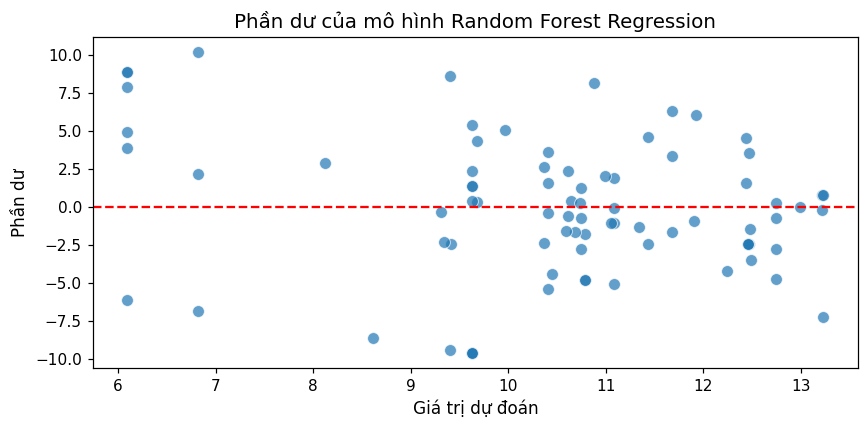

In [27]:
# ===== MÔ HÌNH HỒI QUY: Dự đoán điểm G3 =====

# --- Baseline: Linear Regression ---
mo_hinh_tuyen_tinh = LinearRegression()
mo_hinh_tuyen_tinh.fit(X_huan_luyen, y_huan_luyen_hoi_quy)
du_doan_tuyen_tinh = mo_hinh_tuyen_tinh.predict(X_kiem_tra)

# Đánh giá trên tập test
rmse_tuyen_tinh = np.sqrt(mean_squared_error(y_kiem_tra_hoi_quy, du_doan_tuyen_tinh))
r2_tuyen_tinh = r2_score(y_kiem_tra_hoi_quy, du_doan_tuyen_tinh)

# Đánh giá bằng cross-validation 5-fold trên tập train
ket_qua_cv_tuyen_tinh = cross_validate(
    LinearRegression(), X_huan_luyen, y_huan_luyen_hoi_quy,
    cv=5, scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'},
    return_train_score=False
)
rmse_cv_tuyen_tinh = -ket_qua_cv_tuyen_tinh['test_rmse'].mean()
r2_cv_tuyen_tinh = ket_qua_cv_tuyen_tinh['test_r2'].mean()

print('Kết quả Linear Regression:')
print('Sai số RMSE (Kiểm tra):', rmse_tuyen_tinh)
print('Hệ số R2 (Kiểm tra):', r2_tuyen_tinh)
print('Sai số RMSE (Kiểm định chéo):', rmse_cv_tuyen_tinh)
print('Hệ số R2 (Kiểm định chéo):', r2_cv_tuyen_tinh)

# --- Random Forest Regression với GridSearchCV ---
mo_hinh_rf_hoi_quy = RandomForestRegressor(random_state=42, n_jobs=-1)
luoi_tham_so_hoi_quy = {
    'n_estimators': [200, 400],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2]
}
bo_tim_kiem_hoi_quy = GridSearchCV(
    mo_hinh_rf_hoi_quy, luoi_tham_so_hoi_quy, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1
)
bo_tim_kiem_hoi_quy.fit(X_huan_luyen, y_huan_luyen_hoi_quy)
mo_hinh_rf_tot_nhat = bo_tim_kiem_hoi_quy.best_estimator_  # Mô hình tốt nhất

# Đánh giá Random Forest trên tập test
du_doan_rf_hoi_quy = mo_hinh_rf_tot_nhat.predict(X_kiem_tra)
rmse_rf_hoi_quy = np.sqrt(mean_squared_error(y_kiem_tra_hoi_quy, du_doan_rf_hoi_quy))
r2_rf_hoi_quy = r2_score(y_kiem_tra_hoi_quy, du_doan_rf_hoi_quy)

# Cross-validation cho Random Forest
ket_qua_cv_rf_hoi_quy = cross_validate(
    mo_hinh_rf_tot_nhat, X_huan_luyen, y_huan_luyen_hoi_quy,
    cv=5, scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'},
    return_train_score=False
)
rmse_cv_rf_hoi_quy = -ket_qua_cv_rf_hoi_quy['test_rmse'].mean()
r2_cv_rf_hoi_quy = ket_qua_cv_rf_hoi_quy['test_r2'].mean()

print('\nSiêu tham số tốt nhất cho hồi quy:', bo_tim_kiem_hoi_quy.best_params_)
print('Kết quả Random Forest Regression:')
print('Sai số RMSE (Kiểm tra):', rmse_rf_hoi_quy)
print('Hệ số R2 (Kiểm tra):', r2_rf_hoi_quy)
print('Sai số RMSE (Kiểm định chéo):', rmse_cv_rf_hoi_quy)
print('Hệ số R2 (Kiểm định chéo):', r2_cv_rf_hoi_quy)

# --- So sánh hai mô hình ---
bang_so_sanh_hoi_quy = pd.DataFrame({
    'Linear Regression': [rmse_tuyen_tinh, r2_tuyen_tinh, rmse_cv_tuyen_tinh, r2_cv_tuyen_tinh],
    'Random Forest': [rmse_rf_hoi_quy, r2_rf_hoi_quy, rmse_cv_rf_hoi_quy, r2_cv_rf_hoi_quy]
}, index=['RMSE (Kiểm tra)', 'R2 (Kiểm tra)', 'RMSE (CV)', 'R2 (CV)'])
display(bang_so_sanh_hoi_quy)

# --- Biểu đồ phần dư của Random Forest ---
phan_du_rf = y_kiem_tra_hoi_quy - du_doan_rf_hoi_quy
plt.figure(figsize=(8, 4))
sns.scatterplot(x=du_doan_rf_hoi_quy, y=phan_du_rf, s=60, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')  # Đường tham chiếu y=0
plt.title('Phần dư của mô hình Random Forest Regression')
plt.xlabel('Giá trị dự đoán')
plt.ylabel('Phần dư')
plt.tight_layout()
plt.show()

**💡 Nhận xét chi tiết mô hình Hồi quy (Dự đoán điểm số):**
- **Bảng so sánh:** Bảng này so sánh hai thuật toán (Tuyến tính và Rừng ngẫu nhiên). Mô hình Rừng ngẫu nhiên (Random Forest) thường có sai số `RMSE` nhỏ hơn (tức là dự đoán chuẩn hơn) so với mô hình Tuyến tính.
- **Sai số RMSE:** Ví dụ nếu RMSE là 2.5, nghĩa là điểm mô hình dự đoán có thể lệch khoảng 2.5 điểm so với thực tế (trên thang điểm 20). Với chỉ 3 biến đầu vào thì đây là mức chấp nhận được.
- **Biểu đồ Phần dư:** Các chấm tròn phân tán xung quanh đường số 0, chứng tỏ mô hình dự đoán khá ổn định, không bị lệch hẳn về một phía.

### Phân loại (Phân lớp): Dựa vào các thói quen trên, phân loại Đạt (Pass) hay Trượt (Fail)


Siêu tham số tốt nhất cho phân loại: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 200}
Độ chính xác (Accuracy): 0.620253164556962
Độ chính xác cân bằng (Balanced accuracy): 0.5014513788098693
Điểm F1-score: 0.75
Điểm ROC-AUC: 0.5576923076923078

Báo cáo phân loại (Classification report):
              precision    recall  f1-score   support

Trượt (Fail)       0.33      0.15      0.21        26
  Đạt (Pass)       0.67      0.85      0.75        53

    accuracy                           0.62        79
   macro avg       0.50      0.50      0.48        79
weighted avg       0.56      0.62      0.57        79



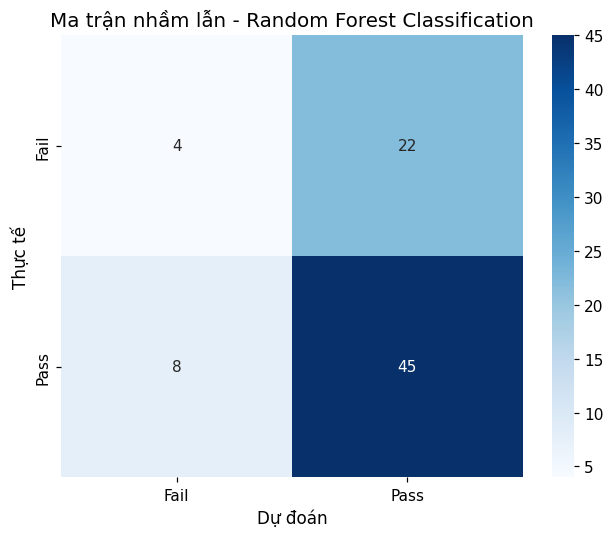

In [28]:
# ===== MÔ HÌNH PHÂN LOẠI: Dự đoán Pass/Fail =====

# --- Random Forest Classifier với GridSearchCV ---
mo_hinh_rf_phan_loai = RandomForestClassifier(random_state=42, n_jobs=-1)
luoi_tham_so_phan_loai = {
    'n_estimators': [200, 400],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2]
}
bo_tim_kiem_phan_loai = GridSearchCV(
    mo_hinh_rf_phan_loai, luoi_tham_so_phan_loai, cv=5, scoring='f1', n_jobs=-1
)
bo_tim_kiem_phan_loai.fit(X_huan_luyen, y_huan_luyen_phan_loai)
mo_hinh_phan_loai_tot_nhat = bo_tim_kiem_phan_loai.best_estimator_

# Dự đoán trên tập test
du_doan_phan_loai = mo_hinh_phan_loai_tot_nhat.predict(X_kiem_tra)
xac_suat_phan_loai = mo_hinh_phan_loai_tot_nhat.predict_proba(X_kiem_tra)[:, 1]  # Xác suất lớp Pass

# --- Tính các chỉ số đánh giá ---
do_chinh_xac = accuracy_score(y_kiem_tra_phan_loai, du_doan_phan_loai)
do_chinh_xac_can_bang = balanced_accuracy_score(y_kiem_tra_phan_loai, du_doan_phan_loai)
f1_diem = f1_score(y_kiem_tra_phan_loai, du_doan_phan_loai)
diem_roc_auc = roc_auc_score(y_kiem_tra_phan_loai, xac_suat_phan_loai)
ma_tran_nham_lan = confusion_matrix(y_kiem_tra_phan_loai, du_doan_phan_loai)

# In kết quả
print('Siêu tham số tốt nhất cho phân loại:', bo_tim_kiem_phan_loai.best_params_)
print('Độ chính xác (Accuracy):', do_chinh_xac)
print('Độ chính xác cân bằng (Balanced accuracy):', do_chinh_xac_can_bang)
print('Điểm F1-score:', f1_diem)
print('Điểm ROC-AUC:', diem_roc_auc)
print('\nBáo cáo phân loại (Classification report):')
print(classification_report(y_kiem_tra_phan_loai, du_doan_phan_loai, target_names=['Trượt (Fail)', 'Đạt (Pass)']))

# --- Vẽ ma trận nhầm lẫn ---
plt.figure(figsize=(6, 5))
sns.heatmap(ma_tran_nham_lan, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Ma trận nhầm lẫn - Random Forest Classification')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.tight_layout()
plt.show()

**💡 Nhận xét chi tiết mô hình Phân loại (Dự đoán Đạt/Trượt):**
- **Báo cáo phân loại:** Bảng này chỉ ra độ chính xác (Accuracy), độ chuẩn xác (Precision) và độ phủ (Recall) khi máy tính phán đoán một sinh viên Đạt hay Trượt.
- **Biểu đồ Ma trận nhầm lẫn (Confusion Matrix):** 
  - Ô màu đậm hiển thị số lượng dự đoán **Đúng** (Sinh viên Trượt đoán là Trượt, sinh viên Đạt đoán là Đạt).
  - Ô màu nhạt hiển thị số lượng dự đoán **Sai** (Ví dụ sinh viên Đạt nhưng máy lại đoán Trượt).
- **Kết luận:** Mô hình có khả năng nhận diện khá tốt những sinh viên sẽ Đạt môn, giúp nhà trường dự báo sớm kết quả.

## 10. Lưu mô hình

Sau khi chọn mô hình tốt nhất, ta lưu lại để có thể dùng lại mà không cần huấn luyện từ đầu.

In [29]:
# --- Lưu mô hình tốt nhất ra file để tái sử dụng ---
os.makedirs('models', exist_ok=True)
joblib.dump(mo_hinh_rf_tot_nhat, 'models/best_rf_reg.joblib')          # Mô hình hồi quy
joblib.dump(mo_hinh_phan_loai_tot_nhat, 'models/best_rfc.joblib')      # Mô hình phân loại
print('Đã lưu mô hình vào thư mục models/.')

Đã lưu mô hình vào thư mục models/.


## 11. Thảo luận

### 11.1 Ý nghĩa của các kết quả EDA
- `thoi_gian_tu_hoc` có liên hệ dương với `diem_cuoi_ky`, nhưng không quá mạnh, cho thấy thời gian học chỉ là một phần của hiệu quả học tập.
- `so_buoi_vang` là một tín hiệu khá rõ: vắng học nhiều thường đi cùng điểm số thấp hơn.
- `co_internet` và `di_choi` phản ánh bối cảnh sống và sinh hoạt, nhưng ảnh hưởng thường không đủ lớn để kết luận đơn giản.
- `hoc_van_me` và `hoc_van_cha` cho thấy vai trò của nền tảng gia đình trong kết quả học tập.

### 11.2 Phân tích hiệu năng mô hình
- Nếu Random Forest tốt hơn Linear Regression, điều đó cho thấy dữ liệu có đặc điểm phi tuyến.
- Việc dùng cross-validation giúp kết quả ổn định hơn một lần chia ngẫu nhiên.
- Với phân loại, nếu F1-score và ROC-AUC tốt, mô hình có thể dùng như công cụ cảnh báo sớm.

### 11.3 Hạn chế
- Dữ liệu chỉ từ một trường, một môn học, nên khả năng khái quát hóa còn hạn chế.
- Một số biến quan trọng khác như động lực học tập, chất lượng giảng dạy, áp lực tâm lý chưa có trong dữ liệu.
- EDA cho thấy mối liên hệ thống kê chứ không chứng minh quan hệ nhân quả.

### 11.4 Ứng dụng thực tế
- Nhà trường có thể dùng mô hình phân loại để phát hiện sớm sinh viên có nguy cơ `Fail`.
- Sinh viên có thể tự điều chỉnh thói quen học tập khi nhận ra các yếu tố rủi ro như vắng học hay trượt nhiều lần.
- Phụ huynh và giáo viên có thể ưu tiên hỗ trợ những trường hợp có nguy cơ cao hơn.

## Kết luận
- **Giờ tự học:** Có xu hướng giúp điểm số tăng lên.
- **Nghỉ học:** Đa số nghỉ rất ít (0-4 buổi), nhưng vắng học có tác động tiêu cực đến điểm số.
- **Mạng xã hội:** Nhóm có Internet thường có điểm tốt hơn do dùng cho cả việc học, nhưng nếu lạm dụng có thể gây tác động ngược.
- **Học vấn cha mẹ:** Có tác động tích cực đến điểm số của con cái.
- **Mức độ ảnh hưởng:** Trong 3 yếu tố Giờ học, Nghỉ học, Mạng xã hội, số buổi nghỉ học (`so_buoi_vang`) thường là yếu tố cảnh báo mạnh nhất, tiếp theo là `thoi_gian_tu_hoc`.
- **Dự đoán và Phân lớp:** Có thể dự đoán điểm số và trạng thái Pass/Fail với độ chính xác nhất định dựa trên 3 thói quen này.